# Cross-price elasticity

Data from `generate_mock_data` with **`cross_elasticity="within_group"`**. Fit **`LogLogDemandModel`** without cross terms vs with **`cross_elasticity`** enabled (same train/test split). A **heatmap** of posterior **γ** coefficients (cross-price effects on mean log quantity) closes the notebook.

From the repository root:

```bash
uv sync
```

MCMC settings in these notebooks use small `draws` / `tune` / `chains` for quick runs. Increase them for production-quality inference.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_alpha, sigma_alpha_group_0, eta_alpha_group_0, sigma_alpha_group_1, eta_alpha_group_1, sigma_alpha_sku, eta_alpha_sku, mu_elasticity, sigma_elasticity_group_0, eta_elasticity_group_0, sigma_elasticity_group_1, eta_elasticity_group_1, sigma_elasticity_sku, eta_elasticity_sku, sigma]
Sampling 2 chains for 150 tune and 150 draw iterations (300 + 300 draws total) took 5 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_alpha, sigma_alpha_group_0, eta_alpha_group_0, sigma_alpha_group_1, eta_alpha_group_1, sigma_alpha_sku, eta_alpha_sku, mu_elasticity, sigma_elasticity_group_0, eta_elasticity_group_0, sigma_elasticity_group_1, eta_elasticity_group_1, sigma_elasticity_sku, eta_elasticity_sku, sigma, mu_cross_pool, sigma_cross_pool, eta_cross_pair]
Sampling 2 chains for 150 tune and 150 draw iterations (300 + 300 draws total) took 6 seconds.

,RMSE,MAE,HDI_94_coverage
model,,,
no cross (hierarchical only),2.380946,1.988604,0.916667
with cross (within_group),2.289061,1.921351,0.958333


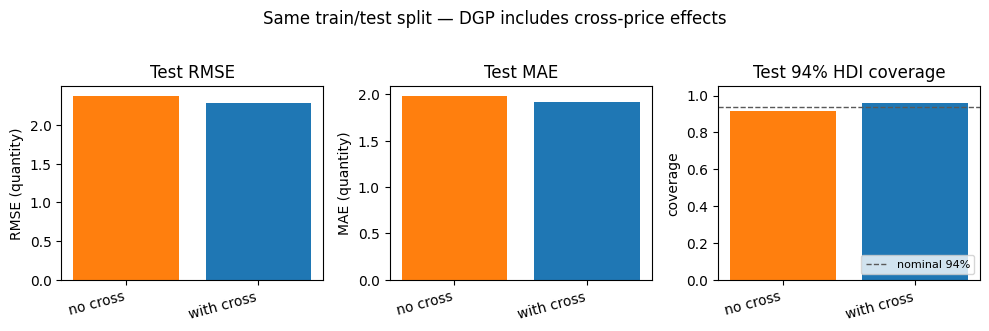

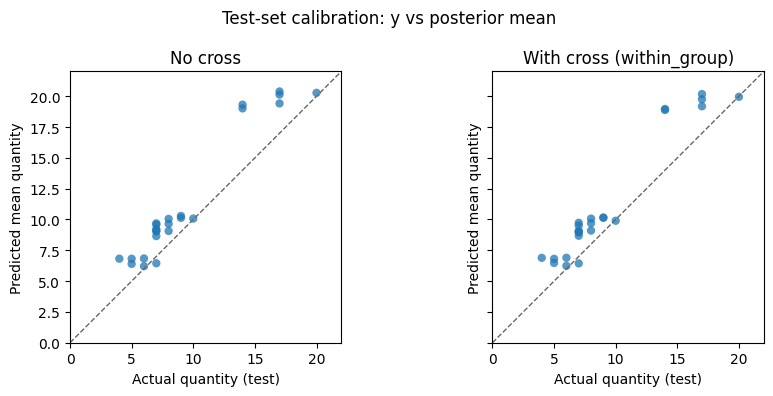

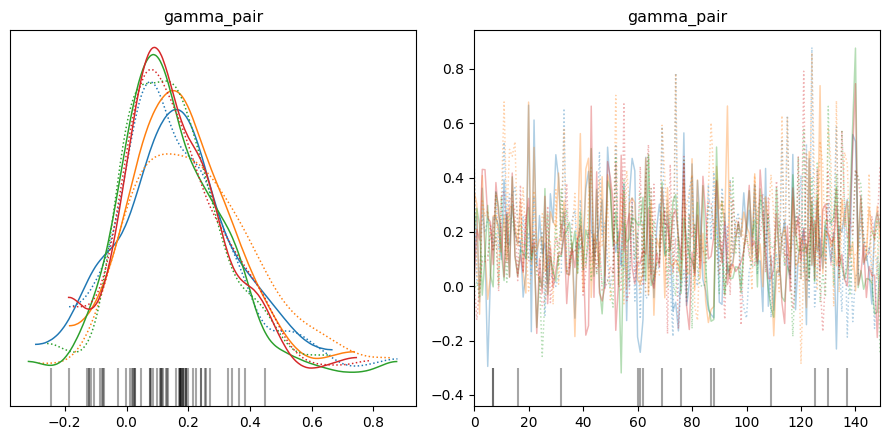

In [3]:
import warnings

warnings.filterwarnings("ignore", message=".*IProgress not found.*")

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from pypricing import (
    CrossElasticitySpec,
    LogLogDemandModel,
    PanelColumns,
    generate_mock_data,
)

RNG = 7
HDI_PROB = 0.94

df_ce = generate_mock_data(
    n_periods=18,
    n_skus=4,
    hierarchy_levels=(2, 2),
    cross_elasticity="within_group",
    cross_elasticity_group_level=0,
    random_state=RNG,
)

panel = PanelColumns(group_columns=("category_1", "category_2"))
cross = CrossElasticitySpec(mode="within_group", group_level=0)
sample_kw = dict(
    draws=150,
    tune=150,
    chains=2,
    random_seed=RNG,
    progressbar=False,
    compute_convergence_checks=False,
)

splitter = LogLogDemandModel(panel_columns=panel)
train_df, test_df = splitter.train_test_split(
    df_ce, test_size=0.28, period_col="period"
)

m_no_x = LogLogDemandModel(panel_columns=panel)
m_no_x.fit(train_df, **sample_kw)
pred_no_x = m_no_x.predict(test_df, hdi_prob=HDI_PROB, random_seed=RNG)

m_x = LogLogDemandModel(panel_columns=panel, cross_elasticity=cross)
m_x.fit(train_df, **sample_kw)
pred_x = m_x.predict(test_df, hdi_prob=HDI_PROB, random_seed=RNG)

y_true = test_df["quantity"].to_numpy(dtype=float)


def eval_preds(name: str, pred: pd.DataFrame) -> dict:
    y_hat = pred["quantity_mean"].to_numpy(dtype=float)
    lo = pred["quantity_hdi_lower"].to_numpy(dtype=float)
    hi = pred["quantity_hdi_upper"].to_numpy(dtype=float)
    return {
        "model": name,
        "RMSE": float(np.sqrt(np.mean((y_true - y_hat) ** 2))),
        "MAE": float(np.mean(np.abs(y_true - y_hat))),
        f"HDI_{int(HDI_PROB * 100)}_coverage": float(
            np.mean((y_true >= lo) & (y_true <= hi))
        ),
    }


rows = [
    eval_preds("no cross (hierarchical only)", pred_no_x),
    eval_preds("with cross (within_group)", pred_x),
]
metrics = pd.DataFrame(rows).set_index("model")
display(metrics)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
labels = [r["model"] for r in rows]
x = np.arange(len(labels))
axes[0].bar(x, metrics["RMSE"].values, color=["C1", "C0"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(["no cross", "with cross"], rotation=15, ha="right")
axes[0].set_ylabel("RMSE (quantity)")
axes[0].set_title("Test RMSE")

axes[1].bar(x, metrics["MAE"].values, color=["C1", "C0"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(["no cross", "with cross"], rotation=15, ha="right")
axes[1].set_ylabel("MAE (quantity)")
axes[1].set_title("Test MAE")

cov_col = f"HDI_{int(HDI_PROB * 100)}_coverage"
axes[2].bar(x, metrics[cov_col].values, color=["C1", "C0"])
axes[2].axhline(HDI_PROB, color="0.35", ls="--", lw=1, label=f"nominal {HDI_PROB:.0%}")
axes[2].set_xticks(x)
axes[2].set_xticklabels(["no cross", "with cross"], rotation=15, ha="right")
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("coverage")
axes[2].set_title(f"Test {int(HDI_PROB * 100)}% HDI coverage")
axes[2].legend(loc="lower right", fontsize=8)

fig.suptitle("Same train/test split — DGP includes cross-price effects", y=1.02)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
lims = [
    0.0,
    float(
        max(
            y_true.max(),
            pred_no_x["quantity_mean"].max(),
            pred_x["quantity_mean"].max(),
        )
        * 1.08
    ),
]
for ax, pred, title in zip(
    axes,
    [pred_no_x, pred_x],
    ["No cross", "With cross (within_group)"],
):
    y_hat = pred["quantity_mean"].to_numpy()
    ax.scatter(y_true, y_hat, alpha=0.75, edgecolors="none")
    ax.plot(lims, lims, ls="--", c="0.4", lw=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual quantity (test)")
    ax.set_ylabel("Predicted mean quantity")
    ax.set_title(title)

fig.suptitle("Test-set calibration: y vs posterior mean")
fig.tight_layout()
plt.show()

az.plot_trace(m_x.idata, var_names=["gamma_pair"], compact=True, figsize=(9, 4.5))
plt.tight_layout()
plt.show()

## Cross-price effects (heatmap)

Directed coefficients **γ** from `gamma_pair`: row = focal SKU, column = competitor whose **log price** enters that focal’s mean log quantity. Diagonal cells are masked (own-price slope is `elasticity_sku`). With **`within_group`**, pairs across categories are absent and show as masked cells.


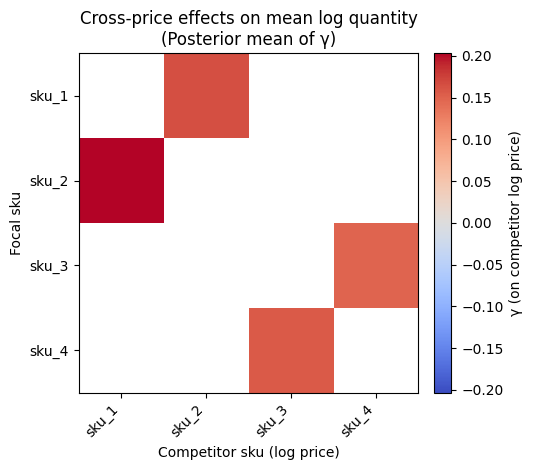

In [4]:
m_x.plot_cross_price_effects_heatmap(agg="mean")
plt.show()